<a href="https://colab.research.google.com/github/nurgissas/ML-personal-learning/blob/main/day06_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6 — One Pipeline to rule them all
**Deliverable checklist — your finished notebook must contain:**
1. ✅ ColumnTransformer handling numeric + categorical + missing values
2. ✅ Full Pipeline ending in XGBoost
3. ✅ GridSearchCV over 2-3 params
4. ✅ New Kaggle submission — score compared to Day 5

> Work top to bottom. **EXAMPLE** cells are done for you — copy the pattern. **TODO** cells are yours. Struggle 30+ min before opening the ✅ Solution sketch in the study app.

**📚 Coding references** *(theory is the videos' job; these teach the code)*: [Pipeline & ColumnTransformer guide](https://scikit-learn.org/stable/modules/compose.html) — the pattern with examples · [Kaggle Learn: Pipelines lesson](https://www.kaggle.com/learn/intermediate-machine-learning)

In [5]:
import pandas as pd, os, kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [6]:
p = kagglehub.competition_download('house-prices-advanced-regression-techniques')
tr = pd.read_csv(os.path.join(p,'train.csv')); te = pd.read_csv(os.path.join(p,'test.csv'))
X = tr.drop(columns=['SalePrice','Id']); y = tr['SalePrice']
num_cols = X.select_dtypes('number').columns
cat_cols = X.select_dtypes('object').columns
print(len(num_cols), 'numeric ·', len(cat_cols), 'categorical')

100%|██████████| 199k/199k [00:00<00:00, 63.0MB/s]

Extracting files...
36 numeric · 43 categorical


In [38]:
from numpy import median
# TODO — build the preprocessor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


pre = ColumnTransformer([
    ('num', SimpleImputer(strategy="median"), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh',  OneHotEncoder(handle_unknown='ignore')),
    ]), cat_cols),
])

In [39]:
# TODO — full pipeline + GridSearchCV
# use sklearn.model_selection's GridSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
params = [('pre', pre), ('xgb', XGBRegressor())]
pipe = Pipeline(params)
grid = {'xgb__n_estimators': [200,500], 'xgb__max_depth': [3,5]}
gs = GridSearchCV(pipe, grid, cv=3, scoring='neg_root_mean_squared_error').fit(X, y)
print(gs.best_params_, -gs.best_score_)

{'xgb__max_depth': 3, 'xgb__n_estimators': 500} 28575.15234375


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size = 0.8, test_size = 0.2, random_state=0)
param_1 = [('pre', pre), ('xgb', XGBRegressor(n_estimators=500, max_depth=3))]
pipe_1 = Pipeline(param_1)
pipe_1.fit(Xtr, ytr)
pred_1 = pipe_1.predict(Xte)
print(mean_absolute_error(yte, pred_1))

17586.01953125


In [29]:
# TODO — predict on te, build submission.csv, submit (same page as Day 5)
param_2 = [('pre', pre), ('xgb', XGBRegressor(n_estimators=600, max_depth=3))]
pipe_2 = Pipeline(param_2)
pipe_2.fit(X, y)
sub_pred = pipe_2.predict(te)
# print(te)

In [30]:
submission = pd.DataFrame({'Id': te.Id, "SalePrice": sub_pred})
submission.to_csv('submission.csv', index=False)

In [31]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**TODO — compare:** Day 5 score `0.14225` vs today `0.14067`. Why does the pipeline version usually win? (hint: 40+ categorical columns were thrown away yesterday). Also: explain in one sentence how the Pipeline prevents data leakage.

## WHY DOES IT HAPPEN?
Pipeline prevents data leakage by making sure that the preprocessing steps (imputation) are fit only on the training data, testing data are not affected -> these fitted transformers are then applied to both the training and test sets, which prevents information from the test set influencing the preprocessing steps.

And there is another point: the categorical data are very important in making predictions, so using imputer rather than throwing away the categorical data are 3rd in feature importance to predicting SalePrice

<Axes: >

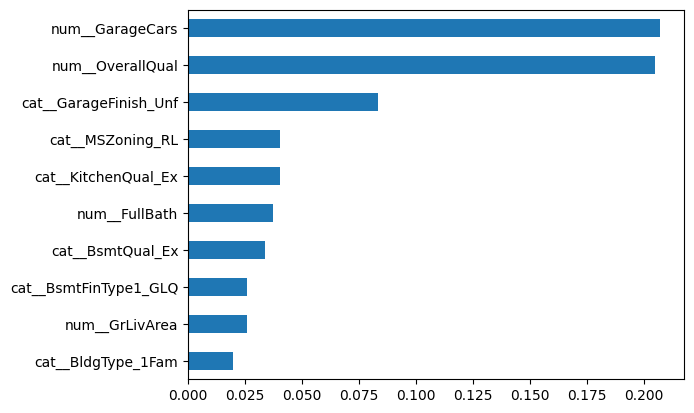

In [36]:
feature_names_out = pipe_2['pre'].get_feature_names_out()
imp = pd.Series(pipe_2['xgb'].feature_importances_, index=feature_names_out).sort_values()
imp.tail(10).plot.barh()

## ✅ Expected outputs checkpoint
Before shipping, verify you see roughly this — if not, debug before moving on:
- GridSearchCV best CV RMSE ≈ **25,000-30,000** dollars
- Leaderboard improves vs Day 5 (typically **0.13-0.14**) — categorical columns carry real signal
- Pipeline predicts on raw `te` directly — no manual preprocessing before predict = leakage-proof